# Market cryptos Classification

## Import Libraries

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import json

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils
from glob import glob

In [2]:
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras
import tensorflow_addons as tfa

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not 

In [3]:
import tensorflow as tf

print("Versão do TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.15.0
GPUs disponíveis: []


In [4]:
import os, sys
processing_source_path = os.path.abspath('./../../../Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import scrapingHistoricalData, FeaturesDataGenerator

import  ProcessingPipeline as pp


## Init parameters

In [5]:

#features_indicators=['Close', 'Open', 'High', 'Low', 'Volume']
pred_days = 25
buy_sell_threshold=[0.05,-0.05]

lookback = 40# 30 # 40

batch_size = 64
shuffle = True
data_augmentation =True

min_norm = -1
max_norm =  1

trade=['Hold','Buy','Sell']

# model parameters
n_classes = len(trade)



### Get the crypto data

In [6]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
#cryptos = ['BTC']
cryptos = ['SOL']

# Escolha o intervalo
interval = '4h'

# Obtenha os dados históricos
cryptos_df = SHD.get_crypto_historical_data(cryptos, interval, '2024-01-01')

## Deep Learning Model

In [7]:
from tensorflow.keras import datasets, layers, models


In [8]:
list_of_models =['CNN_restnet_MultiHead_2D']
checkpoint_filepath =f'models/model_{list_of_models[0]}_crypto_General_last'


# JSON file
with open(f'{checkpoint_filepath}/config.json', 'r') as file:
    parameters = json.load(file)

for parameter in parameters:
    print(f'{parameter}:{parameters[parameter]}')

input_shape = (lookback, len(parameters['features_indicators']))


symbol:['BTC', 'ETH', 'SOL', 'XRP', 'ADA', 'DOT', 'FET', 'ENA', 'NEAR', 'BNB', 'XLM', 'TRX', 'INJ', 'SNX']
model_name:CNN_MultiHead_2D
features_indicators:['SCP', 'RSI_14', 'Williams_R', 'MFI', 'MACD', 'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower', 'CCI', 'ROC', 'Chaikin_Money_Flow']
pred_days:25
buy_sell_threshold:[0.05, -0.05]
lookback:40
batch_size:64
shuffle:True
data_augmentation:True
min_norm:-1
max_norm:1
trade:['Hold', 'Buy', 'Sell']
TH:[0.5, 0.5, 0.5]


In [9]:
parameters['data_augmentation'] = data_augmentation

In [10]:
datatype='2D'
dataGen_inference = FeaturesDataGenerator(
    cryptos_df, 
    datatype=datatype, 
    lookback = parameters['lookback'], 
    pred_days = parameters['pred_days'], 
    shuffle= parameters['shuffle'], 
    batch_size=parameters['batch_size'], 
    selected_features = parameters['features_indicators'], 
    data_augmentation=parameters['data_augmentation'], 
    min_max_norm_features=[parameters['min_norm'], parameters['max_norm']]
)

input data shape (6010, 40, 18)
output data shape (6010, 3)


In [11]:
from keras import backend as K
weighted_categorical_crossentropy_loss= dataGen_inference.weighted_categorical_crossentropy(np.ones(3))

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

import tensorflow_addons as tfa
trained_best_models={}
for model_name in list_of_models:
    print(model_name)
    checkpoint_filepath =f'models/model_{model_name}_crypto_General_last'
    trained_best_models[f'{model_name}']=tf.keras.models.load_model(
        checkpoint_filepath,
        custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient})

CNN_restnet_MultiHead_2D





In [12]:
General_model=trained_best_models[model_name]

In [13]:
General_model.summary()

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 40, 18, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 40, 18, 64)        640       
                                                                 
 batch_normalization (Batch  (None, 40, 18, 64)        256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 40, 18, 64)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 40, 18, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 40, 18, 64)   

In [14]:
# Extract the convolutional layers

# # TO FINE-TUNING ALL DENSE LAYERS
idx=[('flatten' in x.name) for x in General_model.layers].index(True)
parameters['CNN-to-dense compression']=General_model.layers[idx].name

conv_layers_temp=General_model.layers[:idx]
conv_layers_temp[0].get_config()['batch_input_shape']


# freeze the convolutional layers
for layer in General_model.layers[:idx]:
    layer.trainable = False

print('Using the trained dense layers...')

for layer in General_model.layers[:idx]:
    layer._name=layer._name+'_TransferLearning'
    
#FineTuning_model = models.Model(inputs=General_model.input, outputs=General_model.output, name='CNN_MultiHead_2D')

Using the trained dense layers...


In [15]:
General_model.layers

In [16]:
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Dense, Flatten, Reshape
)

factor =2
def head_layer(conv_layer, num_classes, dropout_rate, l2_regularization, activation='softmax', output_name=None):
    x = Flatten()(conv_layer)
    # Densas com regularização
    x = Dense(128*factor, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64*factor, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x

# Definindo parâmetros
input_shape_model = (input_shape[1], input_shape[0], 1)
num_classes = 3
dropout_rate = 0.3
l2_regularization = 0.01

# Extrair as camadas convolucionais do modelo original
idx = [('flatten' in x.name) for x in General_model.layers].index(True)
conv_layers = General_model.layers[:idx]

# Congelar as camadas convolucionais
for layer in conv_layers:
    layer.trainable = False

# Criar um novo modelo com as camadas convolucionais congeladas e novas camadas densas
x = conv_layers[-1].output
x = head_layer(x, num_classes, dropout_rate, l2_regularization, activation='linear', output_name='classification_head')

FineTuning_model = Model(inputs=General_model.input, outputs=x)


FineTuning_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1_TransferLearning (  [(None, 40, 18, 1)]       0         
 InputLayer)                                                     
                                                                 
 conv2d_TransferLearning (C  (None, 40, 18, 64)        640       
 onv2D)                                                          
                                                                 
 batch_normalization_Transf  (None, 40, 18, 64)        256       
 erLearning (BatchNormaliza                                      
 tion)                                                           
                                                                 
 activation_TransferLearnin  (None, 40, 18, 64)        0         
 g (Activation)                                                  
                                                             

In [17]:
# Obtenha os dados históricos
cryptos_df = SHD.get_crypto_historical_data(cryptos, interval, '2024-01-01')

x_data_inference=dataGen_inference.comput_features(cryptos_df, pred_days=0)
x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)

if datatype == '2D':
    x_data_test = np.transpose(x_data, [0, 2, 1]).reshape(-1, input_shape[0], input_shape[1], 1)


In [18]:
y_classification = dataGen_inference.label_data(close_prices=cryptos_df['Close'].values, 
                                                    window=parameters['pred_days'], 
                                                    positive_threshold=buy_sell_threshold[0], 
                                                    negative_threshold=buy_sell_threshold[1])[parameters['lookback']:]
y_classification

array([[1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       ...,
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]])

In [19]:
np.unique(np.argmax(y_classification,axis=1),return_counts= True)

(array([0, 1, 2], dtype=int64), array([2732,  114,  113], dtype=int64))

In [20]:
idx = [('flatten' in x.name) for x in General_model.layers].index(True)

# Crie um modelo que saída seja a saída da camada convolucional antes do Flatten
conv_model = models.Model(inputs=General_model.input, outputs=General_model.layers[idx].output)

# Compile o modelo
conv_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Faça as previsões
features = conv_model.predict(x_data_test)

print(features.shape)


93/93 [==============================] - 10s 97ms/step
(2959, 12800)


In [21]:
conv_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1_TransferLearning (  [(None, 40, 18, 1)]       0         
 InputLayer)                                                     
                                                                 
 conv2d_TransferLearning (C  (None, 40, 18, 64)        640       
 onv2D)                                                          
                                                                 
 batch_normalization_Transf  (None, 40, 18, 64)        256       
 erLearning (BatchNormaliza                                      
 tion)                                                           
                                                                 
 activation_TransferLearnin  (None, 40, 18, 64)        0         
 g (Activation)                                                  
                                                           

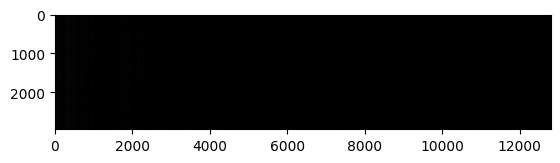

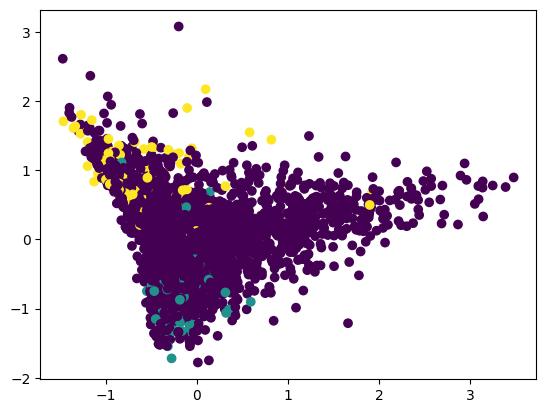

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


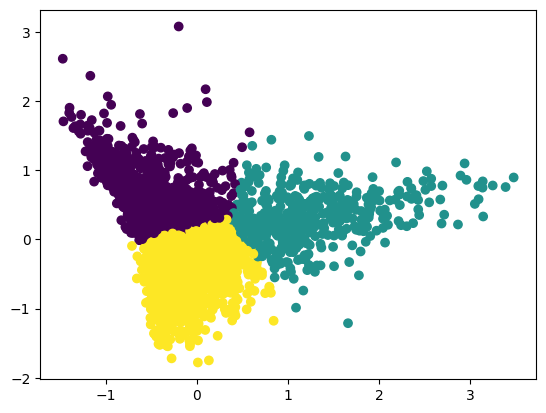

In [22]:
# Visualização
import matplotlib.pyplot as plt
plt.imshow(features, cmap='gray')
plt.show()

# Análise de componentes
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)
plt.scatter(pca_features[:, 0], pca_features[:, 1],  c=np.argmax(y_classification, axis=1))
plt.show()

# Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(pca_features)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans.labels_)
plt.show()

In [23]:
pca_features.shape

(2959, 2)

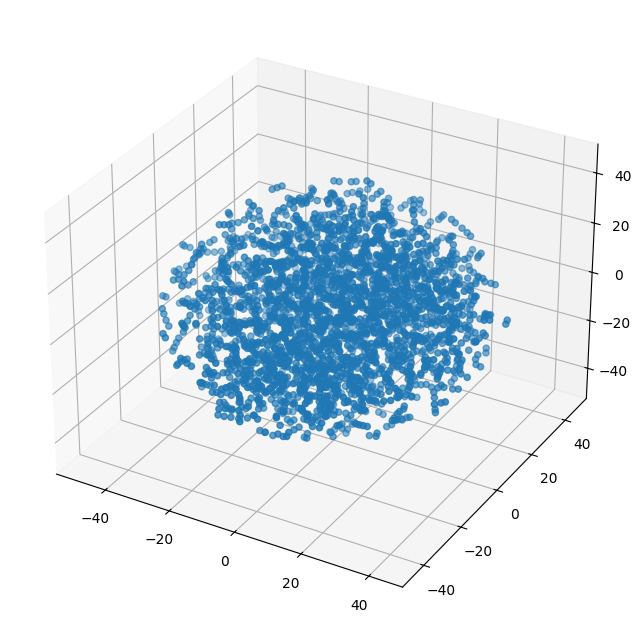

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


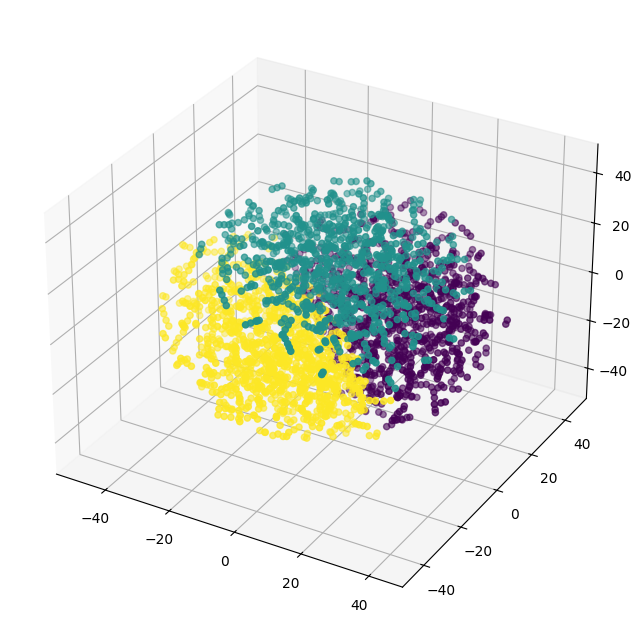

In [24]:
# Análise de componentes em 3D
from sklearn.manifold import TSNE
tsne = TSNE(n_components=3, random_state=42)
tsne_features = tsne.fit_transform(features)

# Plotar as features em 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_features[:, 0], tsne_features[:, 1], tsne_features[:, 2])
plt.show()

# Clustering em 3D
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(tsne_features)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_features[:, 0], tsne_features[:, 1], tsne_features[:, 2], c=kmeans.labels_)
plt.show()

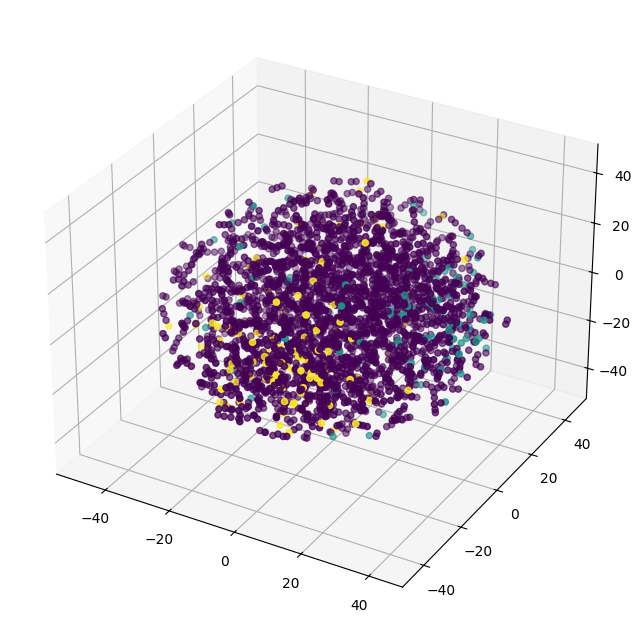

In [25]:
# Plotar os dados em 3D com os labels verdadeiros
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_features[:, 0], tsne_features[:, 1], tsne_features[:, 2], c=np.argmax(y_classification, axis=1))
plt.show()

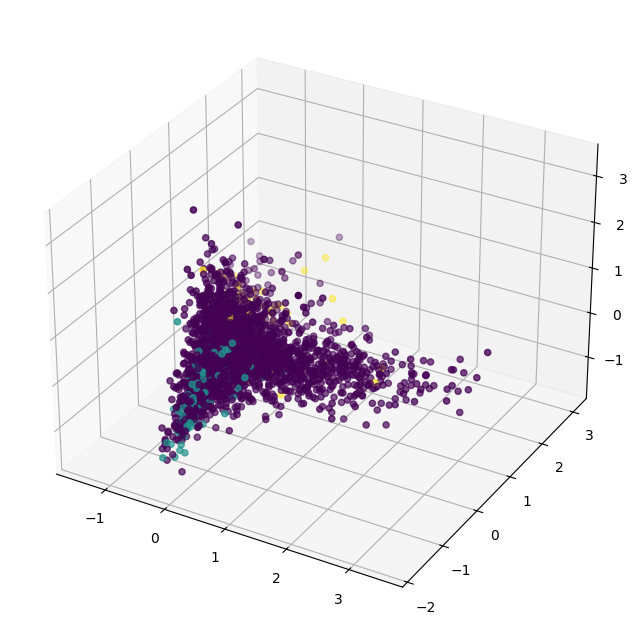

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


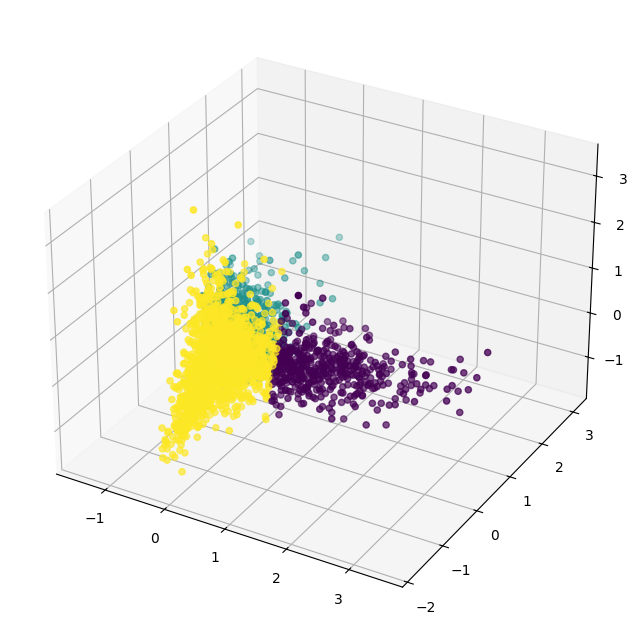

In [26]:
# Análise de componentes em 3D
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_features = pca.fit_transform(features)

# Plotar as features em 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_features[:, 0], pca_features[:, 1], pca_features[:, 2],  c=np.argmax(y_classification, axis=1))
plt.show()

# Clustering em 3D
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(pca_features)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_features[:, 0], pca_features[:, 1], pca_features[:, 2], c=kmeans.labels_)
plt.show()

In [27]:
FineTuning_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1_TransferLearning (  [(None, 40, 18, 1)]       0         
 InputLayer)                                                     
                                                                 
 conv2d_TransferLearning (C  (None, 40, 18, 64)        640       
 onv2D)                                                          
                                                                 
 batch_normalization_Transf  (None, 40, 18, 64)        256       
 erLearning (BatchNormaliza                                      
 tion)                                                           
                                                                 
 activation_TransferLearnin  (None, 40, 18, 64)        0         
 g (Activation)                                                  
                                                             

In [28]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    #optimizer = optimizers.SGD(lr=params["lr"], decay=1e-6, momentum=0.9, nesterov=True)

    return optimizer1
    #

#Train options callbacks

    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.1, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name,symbol):
    checkpoint_filepath =f'models/model_{model_name}_crypto_finetuning_{symbol}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback

model_name = 'CNN_MultiHead_2D'

FineTuning_model._name = model_name
FineTuning_model._name
list_of_models=[FineTuning_model]

## Load Data And train

In [29]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'#


In [30]:
import datetime
init_date = '2023-01-01'
#init_date = '2020-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 2


cryptos_list = ['ADA'] 


if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


In [31]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        # Caminho do arquivo

ADA Dataset Period:2023-01-01 : 2025-06-16


In [32]:
range(0, diff_years-year_window+1)

range(0, 1)

ADA Dataset Period:2023-01-01 : 2025-06-16


The file ./../../../Data_history\ADA_4h_2018-04-17_2025-04-23.csv exist in folder path.
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (11308,)
Vall data shape (1414,)
Test data shape (1415,)
input data shape (19, 1, 30)
output data shape (19, 3)


d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\MarketIndicators.py:97: RuntimeWarning: invalid value encountered in divide
  percent_k = 100 * ((close_prices - lowest_low) / (highest_high - lowest_low))


input data shape (22855, 40, 18)
output data shape (22855, 3)
input data shape (2791, 40, 18)
output data shape (2791, 3)
input data shape (2794, 40, 18)
output data shape (2794, 3)
[0 1 2] [10389  6233  6233]
Training model : models/model_CNN_MultiHead_2D_crypto_finetuning_ADA
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train for model: CNN_MultiHead_2D
Epoch 1/200


357/357 [==============================] - ETA: 0s - loss: 5.4964 - accuracy: 0.6292 - f1_score: 0.6249 - matthews_correlation_coefficient: 0.3272
Epoch 1: val_loss improved from inf to 3.87418, saving model to models\model_CNN_MultiHead_2D_crypto_finetuning_ADA
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_finetuning_ADA\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_finetuning_ADA\assets


...

357/357 [==============================] - 96s 269ms/step - loss: 0.3713 - accuracy: 0.5705 - f1_score: 0.5512 - matthews_correlation_coefficient: 0.2300 - val_loss: 0.3640 - val_accuracy: 0.4691 - val_f1_score: 0.4281 - val_matthews_correlation_coefficient: 0.1570 - lr: 0.0010
Epoch 47/200
357/357 [==============================] - ETA: 0s - loss: 0.3665 - accuracy: 0.5662 - f1_score: 0.5454 - matthews_correlation_coefficient: 0.2345
Epoch 47: val_loss did not improve from 0.36395
357/357 [==============================] - 91s 254ms/step - loss: 0.3665 - accuracy: 0.5662 - f1_score: 0.5454 - matthews_correlation_coefficient: 0.2345 - val_loss: 0.3712 - val_accuracy: 0.5138 - val_f1_score: 0.4657 - val_matthews_correlation_coefficient: 0.2080 - lr: 0.0010
Epoch 48/200
357/357 [==============================] - ETA: 0s - loss: 0.3622 - accuracy: 0.6211 - f1_score: 0.5978 - matthews_correlation_coefficient: 0.2609
Epoch 48: val_loss improved from 0.36395 to 0.35711, saving model to model

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_finetuning_ADA\assets


357/357 [==============================] - 97s 271ms/step - loss: 0.3622 - accuracy: 0.6211 - f1_score: 0.5978 - matthews_correlation_coefficient: 0.2609 - val_loss: 0.3571 - val_accuracy: 0.6101 - val_f1_score: 0.5841 - val_matthews_correlation_coefficient: 0.2113 - lr: 0.0010
Epoch 49/200
357/357 [==============================] - ETA: 0s - loss: 0.3575 - accuracy: 0.6245 - f1_score: 0.6059 - matthews_correlation_coefficient: 0.2559
Epoch 49: val_loss improved from 0.35711 to 0.35246, saving model to models\model_CNN_MultiHead_2D_crypto_finetuning_ADA
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_finetuning_ADA\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_finetuning_ADA\assets


357/357 [==============================] - 95s 267ms/step - loss: 0.3575 - accuracy: 0.6245 - f1_score: 0.6059 - matthews_correlation_coefficient: 0.2559 - val_loss: 0.3525 - val_accuracy: 0.6221 - val_f1_score: 0.6045 - val_matthews_correlation_coefficient: 0.2171 - lr: 0.0010
Epoch 50/200
357/357 [==============================] - ETA: 0s - loss: 0.3616 - accuracy: 0.6032 - f1_score: 0.5904 - matthews_correlation_coefficient: 0.2408
Epoch 50: val_loss did not improve from 0.35246
357/357 [==============================] - 91s 255ms/step - loss: 0.3616 - accuracy: 0.6032 - f1_score: 0.5904 - matthews_correlation_coefficient: 0.2408 - val_loss: 0.3589 - val_accuracy: 0.5912 - val_f1_score: 0.5723 - val_matthews_correlation_coefficient: 0.2047 - lr: 0.0010
Epoch 51/200
357/357 [==============================] - ETA: 0s - loss: 0.3598 - accuracy: 0.5985 - f1_score: 0.5848 - matthews_correlation_coefficient: 0.2319
Epoch 51: val_loss did not improve from 0.35246
357/357 [=================

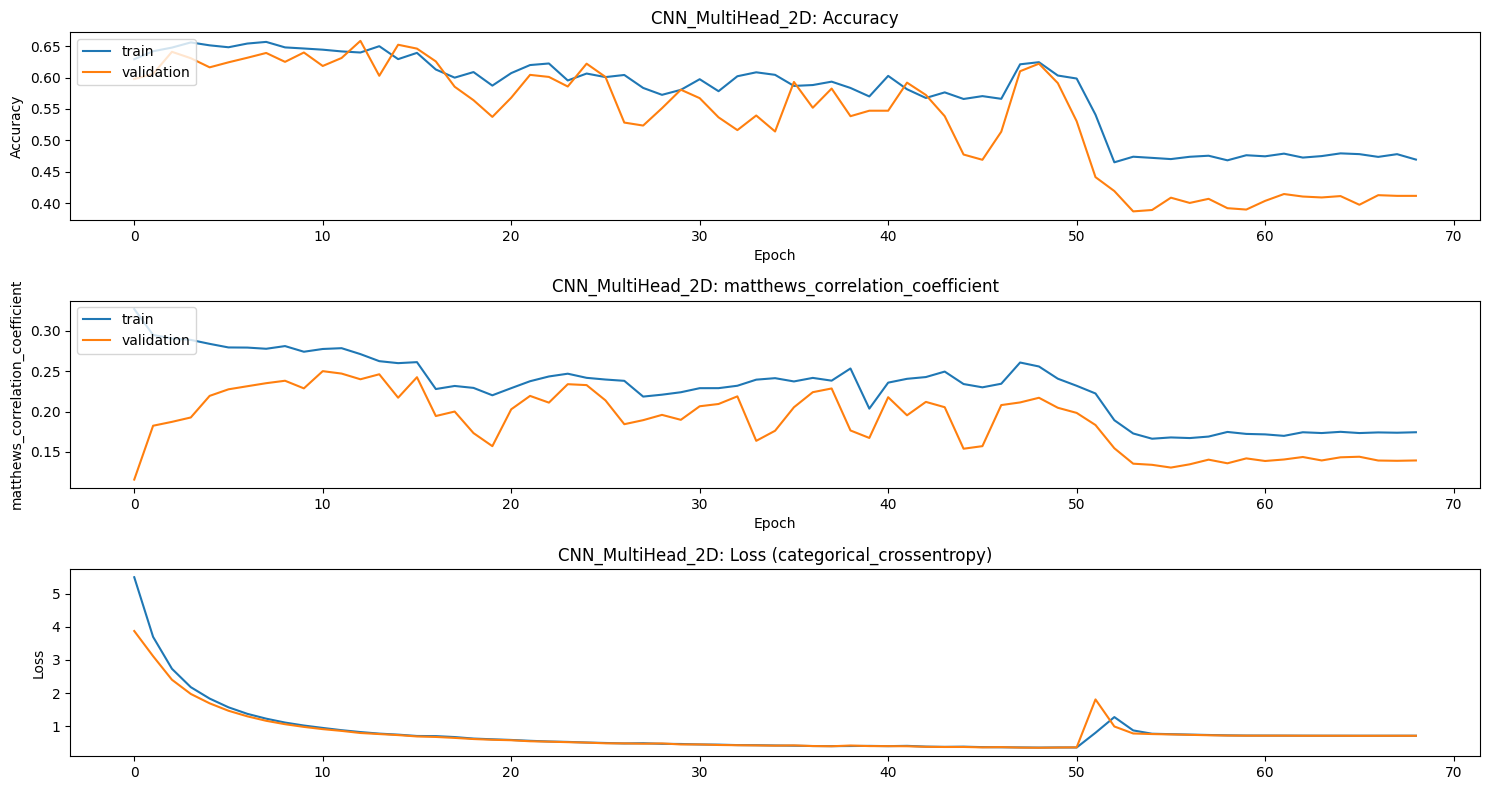

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead_2D
Model name: CNN_MultiHead_2D
88/88 [==============================] - 6s 70ms/step
CNN_MultiHead_2D  classification Accuracy 0.6220472440944882


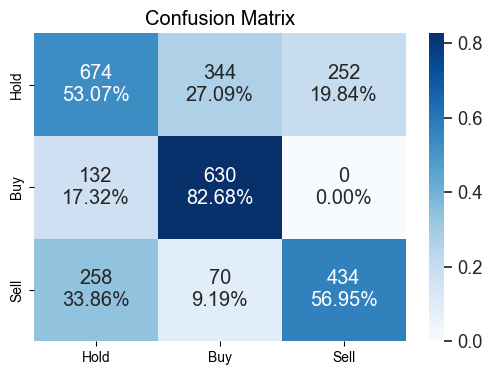

In [33]:
idx=0

for stride_year in range(0, diff_years-year_window+1):
    assets=[]
    for cryptos in cryptos_list:
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        # Caminho do arquivo
        #file_folder = f'Data_history/{cryptos_list[0]}_{interval}_{init_time}_{end_time}.csv'
        try:
            file_folder = [crypto_data for crypto_data in glob("./../../../Data_history/*")  if cryptos in crypto_data][0]
        except:
            file_folder =""
            
        if os.path.exists(file_folder):
            print(f"The file {file_folder} exist in folder path.")
            cryptos_df=pd.read_csv(file_folder, index_col=0)

            #mask = (cryptos_df['Date'] >= init_time) & (cryptos_df['Date'] <= end_time)
            #cryptos_df = cryptos_df[mask]
            
            #cryptos_df.reset_index(drop=True, inplace=True)
            #cryptos_df.to_csv(file_folder)
            #print(f"Save the file {file_folder} in folder path.")
        else:
            print(f"Donwload the file {file_folder} from bincance history.")
            # Obtenha os dados históricos
            cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)

        assets+=[cryptos_df]

    assets_train=[]
    assets_val=[]
    assets_test=[]

    # split the data in train validation and test
    split_data=FeaturesDataGenerator().split_data
    X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
    X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

    print('Train data shape',X_train.shape)
    print('Vall data shape',X_val.shape)
    print('Test data shape',X_test.shape)

    # get the list of assets used in train, val, and test
    for asset  in assets:
        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(asset['Close'].values, asset['Date'], factor=0.80)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        assets_train+=[asset[asset['Date'].isin(T_train)].iloc[:,:]]
        assets_val+=[asset[asset['Date'].isin(T_val)].iloc[:,:]]
        assets_test+=[asset[asset['Date'].isin(T_test)].iloc[:,:]]


    # get train vall and test dataloader

     
    X_data_gen_train = FeaturesDataGenerator(
                        assets_train, 
                        datatype=datatype, lookback = parameters['lookback'], pred_days = parameters['pred_days'], shuffle= parameters['shuffle'], batch_size=parameters['batch_size'], 
                        selected_features = parameters['features_indicators'], data_augmentation=parameters['data_augmentation'], min_max_norm_features=[parameters['min_norm'], parameters['max_norm']]
                        )
      
    regression_targets = [X_data_gen_train.target_min, X_data_gen_train.target_max]

    X_data_gen_val = FeaturesDataGenerator(
                    assets_val, 
                    datatype=datatype, lookback = parameters['lookback'], pred_days = parameters['pred_days'], shuffle= parameters['shuffle'], batch_size=parameters['batch_size'], 
                    selected_features = parameters['features_indicators'], data_augmentation=parameters['data_augmentation'], min_max_norm_features=[parameters['min_norm'], parameters['max_norm']]
                    )
    X_data_gen_test = FeaturesDataGenerator(
                assets_test, 
                datatype=datatype, lookback = parameters['lookback'], pred_days = parameters['pred_days'], shuffle= parameters['shuffle'], batch_size=parameters['batch_size'], 
                selected_features = parameters['features_indicators'], data_augmentation=parameters['data_augmentation'], min_max_norm_features=[parameters['min_norm'], parameters['max_norm']]
                )

    # get classes weigths 
    Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
    n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
    print(n_classes, counts)
    output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

    #print(output_class_weights)
    
    output_class_weights = np.ones(3) 
    weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

    penalty_matrix = np.array([
        [0.0, 1.0, 1.0],  # Penalidade para classificar Hold como Buy ou Sell
        [0.5, 0.0, 2.0],  # Penalidade para classificar Buy como Hold (0.5) ou Sell (2.0)
        [0.5, 2.0, 0.0]   # Penalidade para classificar Sell como Hold (0.5) ou Buy (2.0)
    ])
    weighted_categorical_crossentropy_loss= X_data_gen_train.custom_weighted_categorical_crossentropy(output_class_weights, penalty_matrix)
    
    #weight_dict = {k: (1 - (v / counts.sum())) for k, v in enumerate(counts)}
    #loss = weighted_categorical_crossentropy_loss

    losses= {   #'segmentation_head': MSE, 
                'classification_head': weighted_categorical_crossentropy_loss, 
            }
    
    metrics = {
        #'segmentation_head': [NRMSE],
        'classification_head': ['accuracy', 
                            tfa.metrics.F1Score(num_classes=3, average='weighted'),
                            matthews_correlation_coefficient]
    }
            
    #loss = X_data_gen_train.focal_loss(gamma=2.0, alpha=0.25)
    #loss = keras.losses.CategoricalCrossentropy()
    
    for idx_model, model in enumerate(list_of_models):

        if idx == 0:  
            optimizer = get_optimizer()
            csvLogger, model_checkpoint_callback  = checkpoints(model._name, cryptos)
            model.compile(loss=losses, optimizer=optimizer, metrics=metrics)
            idx=1
        else:
            optimizer = get_optimizer()
            csvLogger, model_checkpoint_callback  = checkpoints(model._name, cryptos)
            model = trained_best_models[model._name]
            model.compile(loss=losses, optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])




        print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
        print(f'Initing train for model: {model._name}')

        history = model.fit(
            X_data_gen_train,
            epochs=200,
            callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
            validation_data=X_data_gen_val,
            #shuffle=True,
            #class_weight=weight_dict,
            #class_weight=dict(enumerate([1, 1, 1])),
            verbose=1
        )
        # Assuming history_metric, history_metric_val, history are defined elsewhere

        fig, axes = plt.subplots(3, 1, figsize=(15, 8))  # Create subplots programmatically

        # Plot accuracy, sharing x-axis with NRMSE
        axes[0].plot(history.history['accuracy'])
        axes[0].plot(history.history['val_accuracy'])
        axes[0].set_title(f'{model._name}: Accuracy')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_xlabel('Epoch')  # Shared x-axis label
        axes[0].legend(['train', 'validation'], loc='upper left')
        
        # Plot accuracy, sharing x-axis with NRMSE
        axes[1].plot(history.history['matthews_correlation_coefficient'])
        axes[1].plot(history.history['val_matthews_correlation_coefficient'])
        axes[1].set_title(f'{model._name}: matthews_correlation_coefficient')
        axes[1].set_ylabel('matthews_correlation_coefficient')
        axes[1].set_xlabel('Epoch')  # Shared x-axis label
        axes[1].legend(['train', 'validation'], loc='upper left')

        # Plot loss
        axes[2].plot(history.history['loss'])
        axes[2].plot(history.history['val_loss'])
        axes[2].set_title(f'{model._name}: Loss (categorical_crossentropy)')
        axes[2].set_ylabel('Loss')

        # Adjust spacing and margins (optional)
        plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

        # Fine-tune spacing (optional)
        plt.tight_layout()

        plt.show()
    trained_best_models={}
    print("---------------------------------------------------------------------------------------------------------------------------------")
    for model in list_of_models:
        print(model.name)
        checkpoint_filepath =f'models/model_{model_name}_crypto_finetuning_{cryptos}'
        trained_best_models[f'{model._name}']=tf.keras.models.load_model(
            checkpoint_filepath, 
            custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient}, 
            compile=False)

        print('Model name:',model_name)

        x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)
        x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, input_shape[0], input_shape[1], 1)
        
        label_pred = trained_best_models[model_name].predict(x_data)
        print(model_name,' classification Accuracy',
                        utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                        np.argmax(label_pred,axis=1),average="micro"))

        cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
        
        try:
            utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
        except:
            print(cf_matrix)


In [34]:
model_name

'CNN_MultiHead_2D'

In [35]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'matthews_correlation_coefficient', 'val_loss', 'val_accuracy', 'val_f1_score', 'val_matthews_correlation_coefficient', 'lr'])

In [36]:
file_folder = [crypto_data for crypto_data in glob("./../../../Data_history/*")  if cryptos in crypto_data][0]

### Save the model parameters to inference

In [37]:
checkpoint_filepath

'models/model_CNN_MultiHead_2D_crypto_finetuning_ADA'

In [38]:
# Salve os dados em um arquivo JSON
with open(f'{checkpoint_filepath}/config.json', 'w') as file:
    json.dump(parameters, file, indent=4)

### Vall Data 

Model name: CNN_MultiHead_2D
88/88 [==============================] - 6s 71ms/step
CNN_MultiHead_2D  classification Accuracy 0.6112504478681476


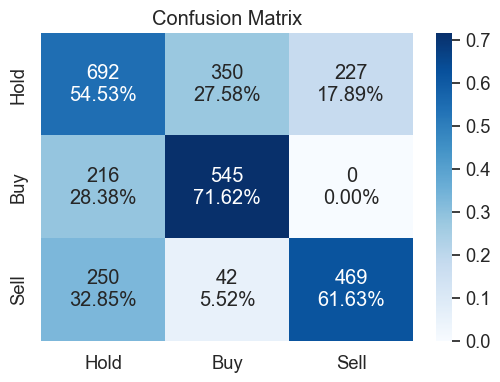

In [39]:
model_name = "CNN_MultiHead_2D"  
print('Model name:',model_name)

x_data=X_data_gen_val.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)
x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, input_shape[0], input_shape[1], 1)

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification,axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

### Backtest

In [40]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data, transaction_cost=0.000001):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []
        self.transaction_cost = transaction_cost
        self.trades = []

    def execute_trade(self, signal, price):
        if signal == 'Buy':
            if self.balance > 0:
                cost = self.balance * self.transaction_cost
                self.position = (self.balance - cost) / price
                self.trades.append({'Action': 'Buy', 'Price': price, 'Position': self.position})
                self.balance = 0
        
        elif signal == 'Sell':
            if self.position > 0:
                proceeds = self.position * price
                cost = proceeds * self.transaction_cost
                self.balance = proceeds - cost
                self.trades.append({'Action': 'Sell', 'Price': price, 'Balance': self.balance})
                self.position = 0

        elif signal not in ['Hold']:
            print('balance:',self.balance)
            print('positi:',self.position)
            raise ValueError(f"Invalid signal: {signal}")

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]
            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_portfolio_value(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_value, label='Portfolio Value')
        plt.title('Portfolio Value Over Time')
        plt.xlabel('Time')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.show()

    def calculate_metrics(self):
        final_portfolio_value = self.portfolio_value[-1]
        roi = (final_portfolio_value - self.initial_balance) / self.initial_balance * 100
        max_drawdown = min(self.portfolio_value) / self.initial_balance - 1
        return {
            'Final Portfolio Value': final_portfolio_value,
            'ROI (%)': roi,
            'Max Drawdown (%)': max_drawdown * 100
        }

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')
        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

input data shape (4954, 40, 18)
output data shape (4954, 3)
155/155 [==============================] - 12s 74ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([1404, 2504, 1046], dtype=int64))


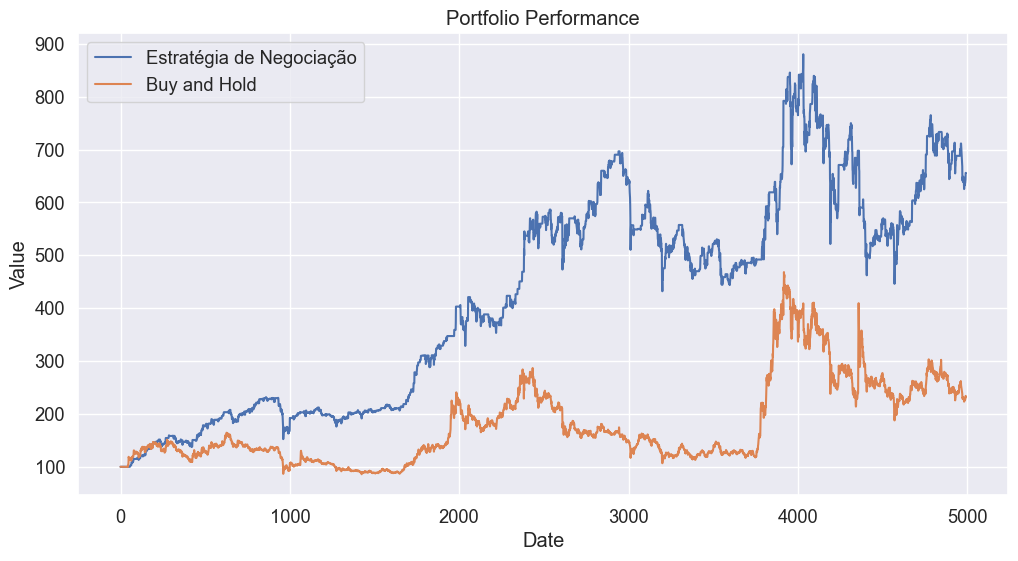

Retorno da Estratégia de Negociação: 555.85%
Retorno da Estratégia de Buy and Hold: 132.79%


In [41]:
# Parâmetros iniciais
#symbol=['BTC']
symbol = [cryptos_list[0]]
interval = '4h' 
start_time = '2023-01-01'
initial_balance = 100

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

dataGen_inference = FeaturesDataGenerator(data, datatype = '2D', lookback = lookback, 
                                          pred_days = pred_days, shuffle= False, 
                                          batch_size=1, selected_features = parameters['features_indicators'], 
                                          data_augmentation=False, 
                                          min_max_norm_features=[min_norm, max_norm])
if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, input_shape[0], input_shape[1], 1)
    
    # list_of_models = ['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead_2D'
    label_pred = trained_best_models[model_name].predict(x_data)

    #signals_model = [trade[label] for label in np.argmax(label_pred[:], axis=1)]


    TH = [0.5, 0.5, 0.5]
    signals_model = np.array([
        trade[np.argmax(prediction)] if np.max(prediction) > TH[np.argmax(prediction)] else trade[0]
        for prediction in label_pred
    ])

    print(np.unique(signals_model, return_counts=True))

    init_signals= ['Hold']*lookback
    
    #trade_signals=init_signals + generate_signals(signals_model)

    trade_signals = init_signals + signals_model.tolist()
    

    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    # backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals =  init_signals + ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

In [42]:
print(f"Modelo: {backtester.calculate_metrics()}")
print(f"BuyHold: {buy_and_hold.calculate_metrics()}")

Modelo: {'Final Portfolio Value': 655.8485965594252, 'ROI (%)': 555.8485965594252, 'Max Drawdown (%)': -0.00010000000000287557}
BuyHold: {'Final Portfolio Value': 232.791975, 'ROI (%)': 132.791975, 'Max Drawdown (%)': -14.105424999999993}


In [43]:
X_data_gen_train.norm_targets.shape

(22855, 1)

In [44]:
label_pred = trained_best_models[model_name].predict(X_data_gen_train[100][0])

2/2 [==============================] - 0s 69ms/step


4994
Calculating labels
4994
Calculating labels


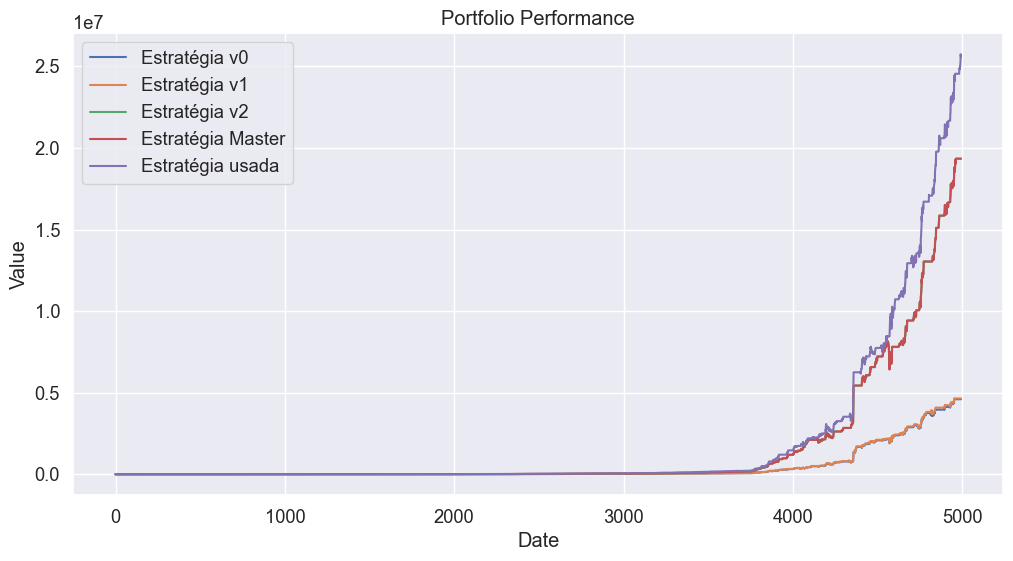

Estratégia v0: 4599202.89%
Estratégia v1: 4647864.60%
Estratégia v2: 19344239.65%
Estratégia Master: 19344239.65%
Estratégia Master Testada: 25594936.70%


In [45]:
# Implementar todas as estratégias
pred_days = 30
label_data_v0 = dataGen_inference.label_data_v0(close_prices=data['Close'].values, window=pred_days)
label_data_v1 = dataGen_inference.label_data_v1(close_prices=data['Close'].values, window=pred_days)
label_data_v2 = dataGen_inference.label_data__(close_prices=data['Close'].values, window=pred_days)
label_data_master = dataGen_inference.label_data_master(close_prices=data['Close'].values, window=pred_days)
label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=pred_days)

# Convertar as labels em sinais de compra e venda
trade_signals_v0 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v0]
trade_signals_v1 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v1]
trade_signals_v2 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v2]
trade_signals_master = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_master]
trade_signals = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data]

# Realizar o backtest
backtester_v0 = Backtester(initial_balance, data)
backtester_v0.run(trade_signals_v0)

backtester_v1 = Backtester(initial_balance, data)
backtester_v1.run(trade_signals_v1)

backtester_v2 = Backtester(initial_balance, data)
backtester_v2.run(trade_signals_v2)

backtester_master = Backtester(initial_balance, data)
backtester_master.run(trade_signals_master)

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester_v0.data.index, backtester_v0.portfolio_value, label='Estratégia v0')
plt.plot(backtester_v1.data.index, backtester_v1.portfolio_value, label='Estratégia v1')
plt.plot(backtester_v2.data.index, backtester_v2.portfolio_value, label='Estratégia v2')
plt.plot(backtester_master.data.index, backtester_master.portfolio_value, label='Estratégia Master')
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia usada')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular o retorno de cada estratégia
retorno_v0 = (backtester_v0.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v1 = (backtester_v1.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v2 = (backtester_v2.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master = (backtester_master.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master_tested = (backtester.portfolio_value[-1] - initial_balance) / initial_balance

# Imprimir os resultados
print(f"Estratégia v0: {retorno_v0 * 100:.2f}%")
print(f"Estratégia v1: {retorno_v1 * 100:.2f}%")
print(f"Estratégia v2: {retorno_v2 * 100:.2f}%")
print(f"Estratégia Master: {retorno_master * 100:.2f}%")
print(f"Estratégia Master Testada: {retorno_master_tested * 100:.2f}%")